In [1]:
import numpy as np
import scanpy as sc
import pandas as pd
import cafe

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

In [2]:
# 读取原本的8W个细胞的数据集
adata = sc.read_h5ad("/root/PyCode/scRNA/data/Gastrulation/gastrulation.h5ad")

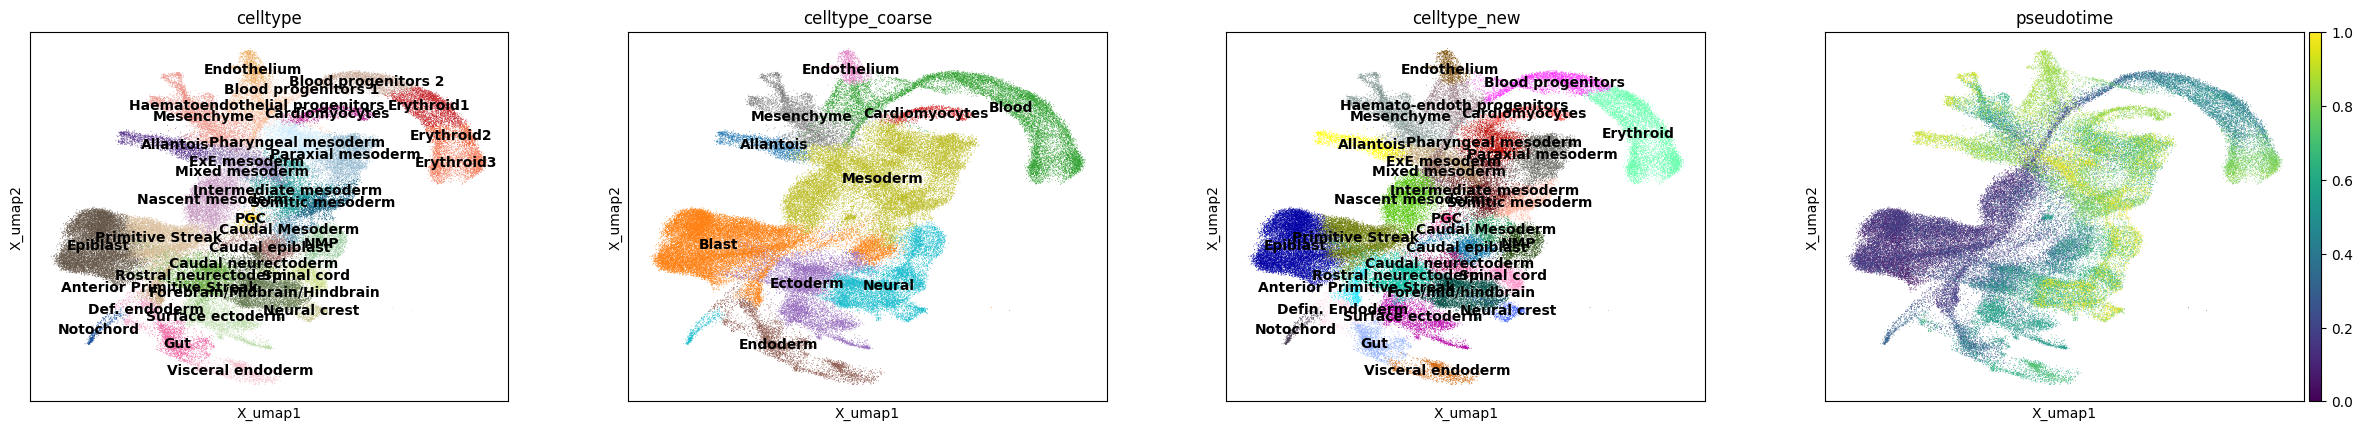

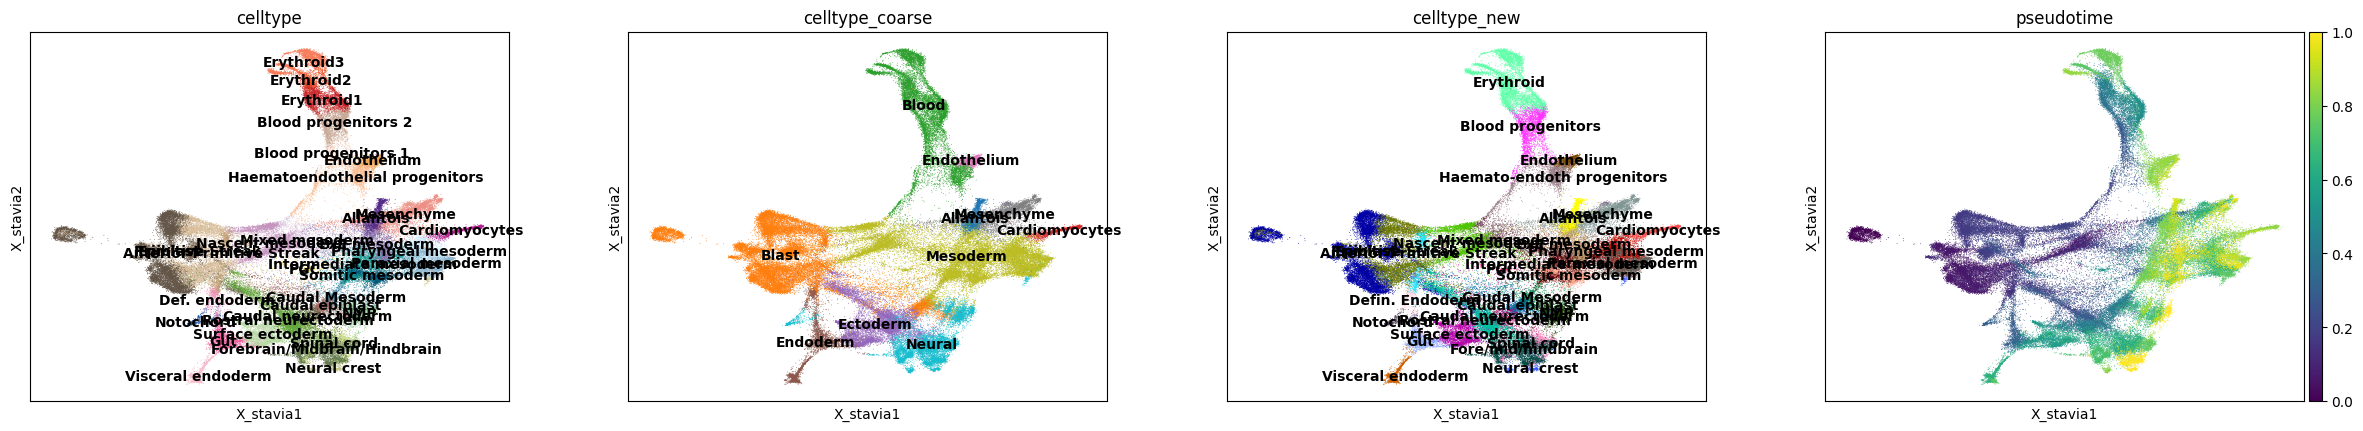

AnnData object with n_obs × n_vars = 89267 × 53801
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom', 'celltype_coarse', 'celltype_new', 'pseudotime'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'celltype_colors', 'id', 'celltype_coarse_colors', 'celltype_new_colors', 'cafe'
    obsm: 'X_pca', 'X_umap', 'X_stavia'
    layers: 'spliced', 'unspliced'

In [3]:
adata.uns["id"]= f"gastrulation"

# 迁移stavia的细胞聚类注释，伪时间
cluster_df = pd.read_csv("gastrulation_cluster.csv", index_col=0)
adata.obs["celltype_coarse"] = cluster_df["celltype_coarse"].tolist()
adata.obs["celltype_new"] = cluster_df["celltype_new"].tolist()
adata.obs["pseudotime"] = np.loadtxt("gastrulation_pseudotime.txt") # stavia pseudotime
adata.obsm["X_stavia"] = np.loadtxt("gastrulation_X_Via2_atlas.txt") # stavia embedding


# 可视化聚类
sc.pl.embedding(adata, basis="X_umap", color=["celltype", "celltype_coarse", "celltype_new", "pseudotime"], frameon="None", legend_loc="on data")
sc.pl.embedding(adata, basis="X_stavia", color=["celltype", "celltype_coarse", "celltype_new", "pseudotime"], frameon="None", legend_loc="on data")

# 转化为FateAnnData对象
fadata = cafe.data.FateAnnData.from_anndata(adata)
fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]
fadata

In [4]:
fadata.prior_information = {
    "cluster": "celltype_coarse",
    "basis": "X_stavia"
}

WARNING  |- Both milestone_percentages and progressions are given, will only use progressions                                                                                                           


array([[<Axes: title={'center': 'ref_coarse_projection(celltype_coarse)'}, xlabel='X_stavia1', ylabel='X_stavia2'>,
        <Axes: title={'center': 'ref_coarse_cluster(celltype_coarse)'}, xlabel='X_stavia1', ylabel='X_stavia2'>]],
      dtype=object)

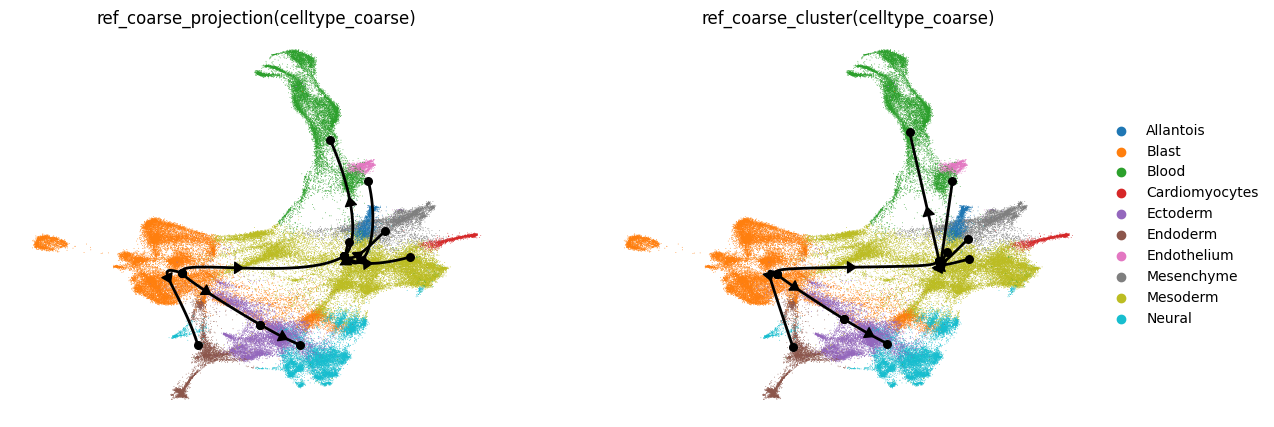

In [5]:
milestone_network = pd.DataFrame(
    data=[
        # Ectoderm related
        ["Blast", "Ectoderm"],
        ["Ectoderm", "Neural"],
        # Mesoderm releated
        ["Blast", "Mesoderm"],
        ["Mesoderm", "Allantois"],
        ["Mesoderm", "Blood"],
        ["Mesoderm", "Cardiomyocytes"],
        ["Mesoderm", "Endothelium"],
        ["Mesoderm", "Mesenchyme"],
        # Endoderm releated
        ["Blast", "Endoderm"],
    ],
    columns=["from", "to"],
)

fadata.prior_information["cluster"] = "celltype_coarse"
fadata.add_trajectory_mannually(milestone_network=milestone_network, wrapper_type="cluster", model_name="ref_coarse_cluster")
fadata.add_trajectory_mannually(milestone_network=milestone_network, wrapper_type="projection", model_name="ref_coarse_projection")
cafe.plot.plot_trajectory(fadata, color="celltype_coarse", model_name=["ref_coarse_projection", "ref_coarse_cluster"])

In [6]:
fadata.write_h5ad("output/26.02.02-gastrulation_case_data/gastrulation.h5ad")